# WEEK 2 DAY 4: AFL Player Performance Investigation

# 1. Loading and Importing


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

info = pd.read_csv('players_info.csv')
season = pd.read_csv('seasonal_stats.csv')
rbr = pd.read_csv('afl_players_round_by_round_stats_raw.csv')

print("players_info:", info.shape)
print("seasonal_stats:", season.shape)
print("round_by_round:", rbr.shape)

players_info: (2843, 16)
seasonal_stats: (25481, 54)
round_by_round: (274089, 36)


In [2]:
rbr.head()

,id,team,year,career_game_count,opponent,round,result,jersey_num,kicks,marks,...,marks_inside_50,one_percenters,bounces,goal_assist,percentage_of_game_played,player_id,match_date,fantasy_points,score,margin
0,556392,Hawthorn Hawks,1994,17,Richmond Tigers,21,W,34,5.0,4.0,...,NaN,NaN,NaN,NaN,NaN,45552,1994-08-14,36,NaN,28
1,614897,Geelong Cats,2024,1,St Kilda Saints,1,W,7,5.0,NaN,...,NaN,1.0,NaN,NaN,26.0,44356,2024-03-16,23,NaN,8
2,583553,Essendon Bombers,1999,97,Adelaide Crows,10,W,6,14.0,5.0,...,NaN,3.0,NaN,NaN,NaN,45955,1999-06-04,67,NaN,48
3,590676,Western Bulldogs,1994,36,St Kilda Saints,21,W,35,12.0,10.0,...,NaN,NaN,NaN,NaN,NaN,45656,1994-08-13,81,NaN,45
4,582473,Richmond Tigers,1997,113,Melbourne Demons,10,L,41,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,45929,1997-05-31,32,NaN,-25


In [3]:
info.head()


,id,player_name,player_full_name,first_name,last_name,born_date,debut_date,debut_age,last_date,last_age,height,weight,profile_pic,player_link,player_common_names,player_teams
0,43261,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,200,100.0,NaN,https://afltables.com/afl/stats/players/R/Ryan...,NaN,"{Geelong Cats,St Kilda Saints}"
1,43262,Gary Ablett,Gary_Ablett1,Gary,Ablett,1984-05-14,2002-03-30,17,2020-10-24,36,182,87.0,NaN,https://afltables.com/afl/stats/players/G/Gary...,NaN,"{Geelong Cats,Gold Coast Suns}"
2,43276,Leek Aleer,Leek_Aleer,Leek,Aleer,2001-08-21,2022-07-30,20,2025-09-06,24,195,85.0,https://res.cloudinary.com/dijzdikkh/image/upl...,https://afltables.com/afl/stats/players/L/Leek...,NaN,NaN
3,43264,Nathan Ablett,Nathan_Ablett,Nathan,Ablett,1985-12-13,2005-08-12,19,2011-08-28,25,195,95.0,NaN,https://afltables.com/afl/stats/players/N/Nath...,NaN,"{Geelong Cats,Gold Coast Suns}"
4,43265,Cain Ackland,Cain_Ackland,Cain,Ackland,1982-03-16,2001-03-30,19,2008-05-16,26,196,101.0,NaN,https://afltables.com/afl/stats/players/C/Cain...,NaN,"{Carlton Blues,Port Adelaide Power,St Kilda Sa..."


In [4]:
season.head()


,player_id,year,team,is_finals,games_played,kicks,marks,handballs,disposals,goals,...,avg_contested_possessions,avg_uncontested_possessions,avg_contested_marks,avg_marks_inside_50,avg_one_percenters,avg_bounces,avg_goal_assists,avg_score,avg_fantasy_points,avg_percentage_played
0,43261,2018,Geelong Cats,False,3,17.0,9.0,21.0,38.0,3.0,...,6.7,6.7,0.3,1.7,4.3,0.0,0.3,6.7,92.7,84.3
1,43261,2018,Geelong Cats,True,1,3.0,2.0,2.0,5.0,0.0,...,2.0,3.0,1.0,1.0,5.0,0.0,0.0,1.0,61.0,81.0
2,43261,2019,Geelong Cats,False,1,5.0,3.0,6.0,11.0,1.0,...,6.0,8.0,0.0,1.0,3.0,0.0,0.0,6.0,74.0,83.0
3,43261,2020,St Kilda Saints,False,1,2.0,2.0,1.0,3.0,1.0,...,0.0,3.0,0.0,1.0,0.0,0.0,0.0,6.0,22.0,54.0
4,43262,2002,Geelong Cats,False,12,37.0,13.0,63.0,100.0,10.0,...,5.7,3.0,0.2,0.2,1.0,0.2,0.0,5.3,36.9,0.0


In [5]:
missing_pct = rbr.isnull().mean().sort_values(ascending=False)
print(missing_pct.head(15))

score                        1.000000
brownlow_votes               0.403084
goal_assist                  0.377979
bounces                      0.355151
hit_outs                     0.352546
marks_inside_50              0.333388
contested_marks              0.330830
behinds                      0.295864
goals                        0.272674
percentage_of_game_played    0.254231
clearances                   0.233205
rebound_50s                  0.229327
one_percenters               0.219440
free_kicks_for               0.196440
free_kicks_against           0.194371
dtype: float64


# 2. Cleaning and Merging


**Observation:** A lot of "NULL"s in stat columns like hit_outs, bounces, goal_assist, marks_inside_50 etc. These aren't really missing data in the traditional sense, they're 0s that just weren't recorded for that player in that game (e.g. a small forward will never record a `hit_out`, so it's NULL instead of 0). I'm treating NULLs in all counting-stat columns as 0.

The score column is 100% NULL so I'm dropping it it's not usable

I also noticed the round column has both numbers  and finals codes (ef, qf, sf etc). 

In [6]:
rbr_clean = rbr.drop(columns=['score']).copy()

count_cols = ['kicks','marks','handballs','disposals','goals','behinds','hit_outs','tackles',
              'rebound_50s','inside_50s','clearances','clangers','free_kicks_for','free_kicks_against',
              'brownlow_votes','contested_possessions','uncontested_possessions','contested_marks',
              'marks_inside_50','one_percenters','bounces','goal_assist']
rbr_clean[count_cols] = rbr_clean[count_cols].fillna(0)

rbr_clean = rbr_clean[rbr_clean['round'].str.isnumeric()].copy()
rbr_clean['round'] = rbr_clean['round'].astype(int)

# duplicate check
print("Duplicate rows in round-by-round:", rbr_clean.duplicated().sum())
print("Duplicate player-year rows in seasonal_stats:", season.duplicated(subset=['player_id','year','is_finals']).sum())
print("Duplicate player ids in players_info:", info['id'].duplicated().sum())

rbr_clean.shape

Duplicate rows in round-by-round: 10
Duplicate player-year rows in seasonal_stats: 0
Duplicate player ids in players_info: 0


(261287, 35)

No duplicate ids/rows in the other two datasets, so those are clean as-is.

**Merging plan:**
afl_players_round_by_round_stats_raw (cleaned) + `players_info` 
I'm merging on `player_id` (round-by-round / seasonal_stats) -->`id` (players_info)

Since I'm trying to find players worth backing for the upcom nf season, I'm using **2025** (the most recent completed season in the data) as the main season of analysis

I also filtered out players with fewer than **10 games played** in 2025: a player with 1-2 games has stats that are way too noisy to judge fairly

In [9]:
season_25 = season[(season['year'] == 2025) & (season['is_finals'] == False)].copy()
season_25 = season_25[season_25['games_played'] >= 10].copy()
season_25 = season_25.merge(info[['id','player_name']], left_on='player_id', right_on='id', how='left')

rbr_25 = rbr_clean[rbr_clean['year'] == 2025].copy()
rbr_25 = rbr_25.merge(info[['id','player_name']], left_on='player_id', right_on='id', how='left')

print("Players qualifying (>=10 games in 2025):", season_25.shape[0])

Players qualifying (>=10 games in 2025): 455


# 3. Feature Engineering

I built 5 new features:

1. **goals_per_game** = raw goal totals reward players who just play more games. Per-game rate is the fair comparison for a goalkicker.
2. **disposal_efficiency** : 1 - (clangers / disposals). Tells us how "clean" a player is with the ball, someone with 25 disposals but 8 clangers isn't actually more valuable than someone with 20 disposals and 2 clangers.
3. **contested_rate** :contested_possessions / (contested + uncontested possessions). Shows whether a player wins the ball under pressure (inside contests) vs mostly gets it in space 
4. **tackle_rate** : tackles per game. A simple pressure/defensive-effort indicator, independent of how much of the ball they get.
5. **score_involvement** :(goals*6 + behinds) / games_played. Approximates how many points per game a player is directly responsible for scoring

In [10]:
season_25['goals_per_game']     = season_25['goals'] / season_25['games_played']
season_25['disposal_efficiency'] = 1 - (season_25['clangers'] / season_25['disposals'].replace(0, np.nan))
season_25['contested_rate']      = season_25['contested_possessions'] / (season_25['contested_possessions'] + season_25['uncontested_possessions'])
season_25['tackle_rate']         = season_25['tackles'] / season_25['games_played']
season_25['score_involvement']   = (season_25['goals'] * 6 + season_25['behinds']) / season_25['games_played']

season_25[['player_name','goals_per_game','disposal_efficiency','contested_rate','tackle_rate','score_involvement']].describe().T

,count,mean,std,min,25%,50%,75%,max
goals_per_game,455.0,0.528358,0.600312,0.000000,0.100000,0.307692,0.739130,3.608696
disposal_efficiency,455.0,0.830577,0.051819,0.664516,0.799126,0.836991,0.867598,0.933190
contested_rate,455.0,0.377997,0.100067,0.146429,0.302331,0.368201,0.444941,0.780347
tackle_rate,455.0,2.620996,1.396835,0.200000,1.687500,2.260870,3.222332,8.913043
score_involvement,455.0,3.552743,3.907987,0.000000,0.879227,2.153846,5.021739,23.217391


# 4. Task 1: Performance Index & Top 10 Most Valuable Players
The stuff i chose for it:

**avg_fantasy_points:**	Gives an overall picture of a player's performance.

**avg_disposals:**	Shows how much the player is involved in the game.

**avg_goals** Measures how much the player contributes to scoring.

**avg_tackles**:	Shows defensive effort and pressure on opponents.

**avg_contested_possessions**:	Measures how well the player wins the ball under pressure.



**How I ranked players:** since these stats are on completely different scales I standardized each one (z-score) and averaged the 5 z-scores into one `performance_index`. This means each stat contributes equally regardless of its original scale.

In [11]:
index_cols = ['avg_fantasy_points','avg_disposals','avg_goals','avg_tackles','avg_contested_possessions']
z = (season_25[index_cols] - season_25[index_cols].mean()) / season_25[index_cols].std()
season_25['performance_index'] = z.mean(axis=1)

top10_valuable = season_25.sort_values('performance_index', ascending=False).head(10)
top10_valuable[['player_name','team','games_played','avg_fantasy_points','avg_disposals','avg_goals','avg_tackles','performance_index']]

,player_name,team,games_played,avg_fantasy_points,avg_disposals,avg_goals,avg_tackles,performance_index
232,Matt Rowell,Gold Coast Suns,23,101.2,26.1,0.4,8.7,2.232279
429,Marcus Bontempelli,Western Bulldogs,18,111.3,27.1,1.2,5.4,1.986102
63,Jordan Dawson,Adelaide Crows,23,110.2,23.7,0.7,7.6,1.857685
32,Jye Caldwell,Essendon Bombers,11,103.6,25.9,0.5,6.7,1.838280
70,Josh Dunkley,Brisbane Lions,23,107.5,25.1,0.2,7.6,1.832224
377,Bailey Smith,Geelong Cats,20,116.3,31.6,0.3,5.0,1.795430
362,Tom Green,Greater Western Sydney Giants,22,97.5,29.5,0.6,3.6,1.770982
402,George Hewett,Carlton Blues,23,98.9,28.1,0.3,5.7,1.768941
23,Andrew Brayshaw,Fremantle Dockers,23,101.0,26.7,0.3,6.7,1.700865
137,Tom Liberatore,Western Bulldogs,23,99.6,26.5,0.3,5.6,1.633124


**Visualization 1: Top 10 Most Valuable Players (Performance Index)**

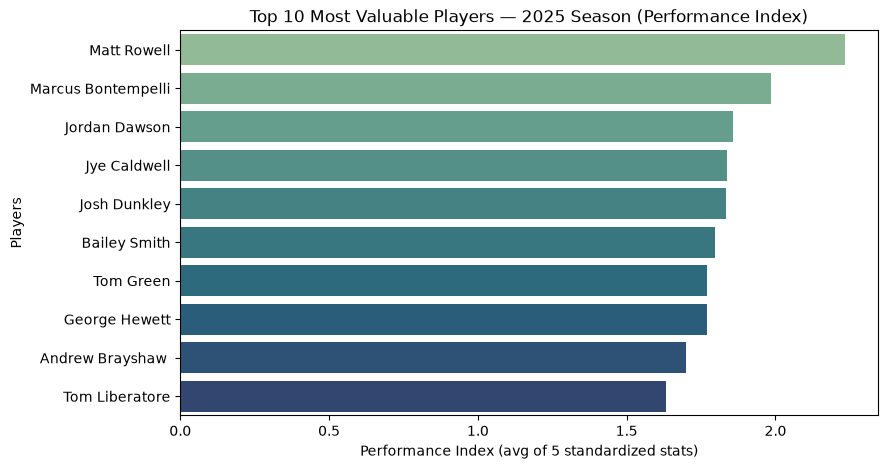

In [12]:
plt.figure(figsize=(9,5))
sns.barplot(data=top10_valuable, y='player_name', x='performance_index', hue='player_name', palette='crest', legend=False)
plt.title('Top 10 Most Valuable Players — 2025 Season (Performance Index)')
plt.xlabel('Performance Index (avg of 5 standardized stats)')
plt.ylabel("Players")
plt.show()

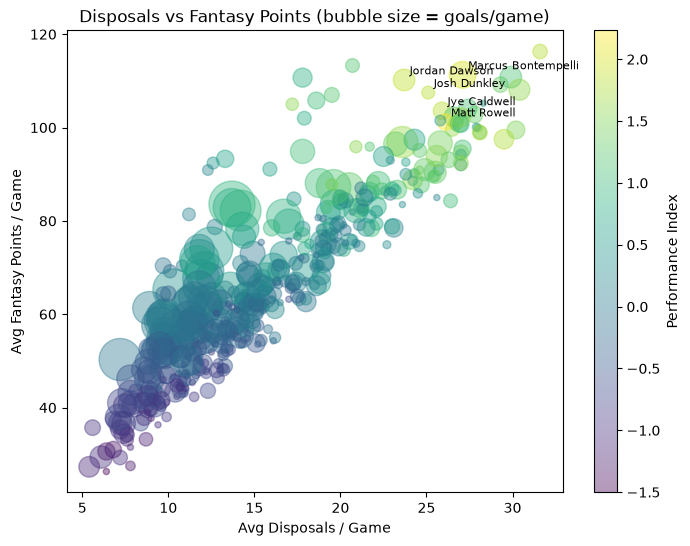

In [13]:
plt.figure(figsize=(8,6))
sc = plt.scatter(season_25['avg_disposals'], season_25['avg_fantasy_points'],
                  s=season_25['goals_per_game']*300 + 20, alpha=0.4, c=season_25['performance_index'], cmap='viridis')
for _, row in top10_valuable.head(5).iterrows():
    plt.annotate(row['player_name'], (row['avg_disposals'], row['avg_fantasy_points']), fontsize=8, xytext=(4,4), textcoords='offset points')
plt.colorbar(sc, label='Performance Index')
plt.xlabel('Avg Disposals / Game')
plt.ylabel('Avg Fantasy Points / Game')
plt.title('Disposals vs Fantasy Points (bubble size = goals/game)')
plt.show()

# 5. Task 2: Most Consistent Players

For this I switched to the round-by-round data, since consistency is about how stable a player's output is *week to week*, not just their season average.

**Method:** For every player with at least 10 rounds played in 2025, I calculated the **coefficient of variation (CV)** of their fantasy_points per round:

**CV = std(fantasy_points) / mean(fantasy_points)**

A lower CV = more consistent

In [14]:
rounds_played = rbr_25.groupby('player_id')['fantasy_points'].count()
qualified_ids = rounds_played[rounds_played >= 10].index

consistency = rbr_25[rbr_25['player_id'].isin(qualified_ids)].groupby('player_id')['fantasy_points'].agg(['mean','std','count']).reset_index()
consistency['cv'] = consistency['std'] / consistency['mean']
consistency = consistency.merge(info[['id','player_name']], left_on='player_id', right_on='id')
consistency = consistency[consistency['mean'] > 40]

top10_consistent = consistency.sort_values('cv').head(10)
top10_consistent[['player_name','mean','std','cv','count']]

,player_name,mean,std,cv,count
444,Tom McCarthy,83.500000,10.113248,0.121117,10
189,Rory Laird,92.550000,14.001786,0.151289,20
13,Tom Atkins,87.782609,14.064645,0.160221,23
282,Christian Petracca,90.391304,14.584360,0.161347,23
105,Tim English,110.739130,18.793658,0.169711,23
48,Finn Callaghan,98.950000,16.928565,0.171082,20
339,Bailey Smith,116.300000,20.058074,0.172468,20
129,Jack Graham,82.666667,14.266373,0.172577,18
55,Adam Cerra,95.052632,16.547822,0.174091,19
131,Tom Green,97.545455,16.989429,0.174169,22


**Visualization 3: Most Consistent Players (lowest CV, min 40 avg fantasy pts)**

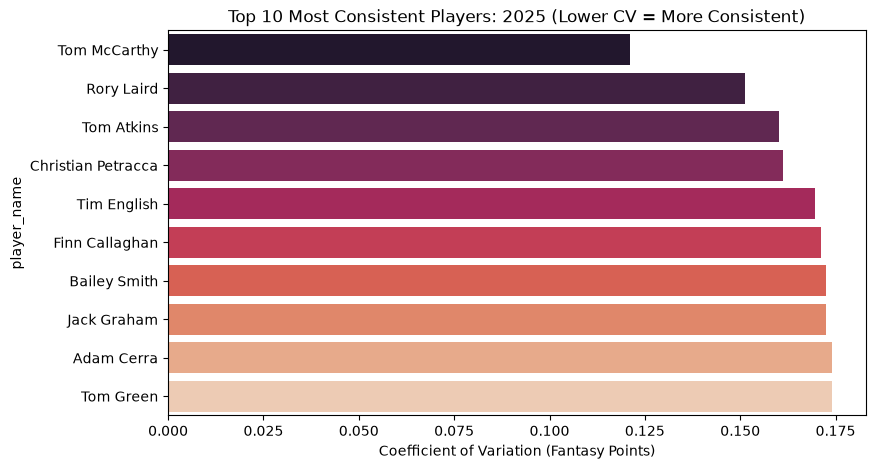

In [15]:
plt.figure(figsize=(9,5))
sns.barplot(data=top10_consistent, y='player_name', x='cv', hue='player_name', palette='rocket', legend=False)
plt.title('Top 10 Most Consistent Players: 2025 (Lower CV = More Consistent)')
plt.xlabel('Coefficient of Variation (Fantasy Points)')

plt.show()

**Visualization 4: Week-to-week fantasy points for the 5 most consistent players**

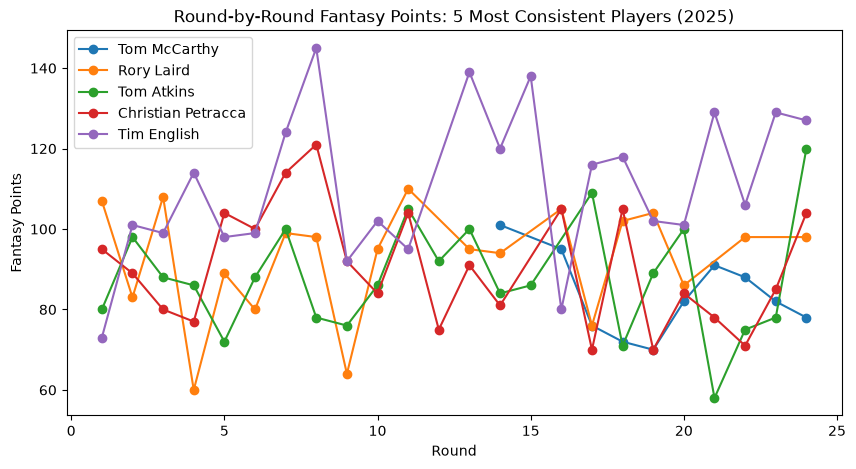

In [16]:
top5_ids = top10_consistent.head(5)['player_id'].values
plot_df = rbr_25[rbr_25['player_id'].isin(top5_ids)].sort_values('round')

plt.figure(figsize=(10,5))
for pid in top5_ids:
    p = plot_df[plot_df['player_id']==pid]
    plt.plot(p['round'], p['fantasy_points'], marker='o', label=p['player_name'].iloc[0])
plt.xlabel('Round')
plt.ylabel('Fantasy Points')
plt.title('Round-by-Round Fantasy Points: 5 Most Consistent Players (2025)')
plt.legend()

plt.show()

**Insight:** We can see how flat these lines are compared to a normal player. That's exactly what "consistent" looks like. 

# 6. Task 3: Performance Trends (Improved vs Declined)

**Method:** I split the 2025 season into two halves: Rounds 1-12 (first half) and Rounds 13+ (second half). and compared each player's average fantasy points in each half. 

`delta = second_half_avg - first_half_avg`.


In [17]:
rbr_25['half'] = np.where(rbr_25['round'] <= 12, 'first', 'second')

half_counts = rbr_25.groupby(['player_id','half']).size().unstack()
half_avg = rbr_25.groupby(['player_id','half'])['fantasy_points'].mean().unstack()
half_avg['delta'] = half_avg['second'] - half_avg['first']

trend = half_avg[(half_counts['first'] >= 4) & (half_counts['second'] >= 4)].copy().reset_index()
trend = trend.merge(info[['id','player_name']], left_on='player_id', right_on='id')

most_improved = trend.sort_values('delta', ascending=False).head(5)
most_declined = trend.sort_values('delta').head(5)

print("MOST IMPROVED")
display(most_improved[['player_name','first','second','delta']])
print("MOST DECLINED")
display(most_declined[['player_name','first','second','delta']])

MOST IMPROVED


,player_name,first,second,delta
102,Francis Evans,35.250000,74.333333,39.083333
66,Lachlan Cowan,41.833333,79.500000,37.666667
212,Colby McKercher,60.909091,94.583333,33.674242
161,Jarman Impey,59.600000,93.272727,33.672727
104,Brayden Fiorini,61.000000,94.083333,33.083333


MOST DECLINED


,player_name,first,second,delta
92,Mitch Duncan,69.800000,32.000000,-37.800000
199,Nic Martin,106.727273,77.000000,-29.727273
393,Riley Bice,65.454545,37.400000,-28.054545
150,Nick Holman,46.900000,19.666667,-27.233333
288,Matt Roberts,91.583333,65.000000,-26.583333


**Visualization 5: Most Improved vs Most Declined Players (2nd half - 1st half avg fantasy points)**

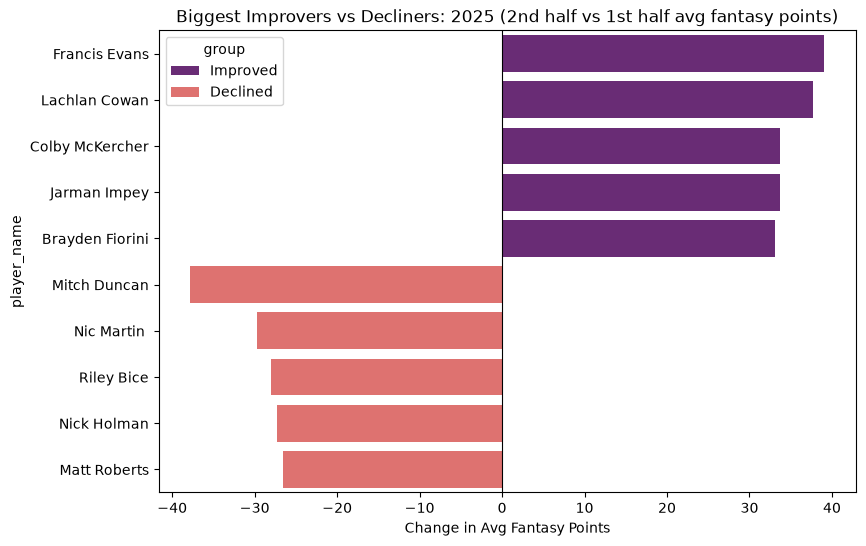

In [18]:
trend_plot = pd.concat([most_improved.assign(group='Improved'), most_declined.assign(group='Declined')])
plt.figure(figsize=(9,6))
sns.barplot(data=trend_plot, y='player_name', x='delta', hue='group', palette = 'magma')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Biggest Improvers vs Decliners: 2025 (2nd half vs 1st half avg fantasy points)')
plt.xlabel('Change in Avg Fantasy Points')

plt.show()

# 7. Task 4: Team Performance Analysis

**Metrics** average `avg_fantasy_points` across all qualifying players (>=10 games) per team in 2025. I used fantasy points because it's the one stat in the dataset that already blends scoring, disposals, tackles and clearances into a single per-player value 


In [19]:
team_rank = season_25.groupby('team')['avg_fantasy_points'].mean().sort_values(ascending=False).reset_index()
team_rank.columns = ['team','avg_team_fantasy_points']
team_rank

,team,avg_team_fantasy_points
0,Geelong Cats,71.012500
1,Western Bulldogs,70.308696
2,Hawthorn Hawks,69.216667
3,Brisbane Lions,69.138462
4,Carlton Blues,67.940000
5,Melbourne Demons,67.300000
6,Essendon Bombers,67.100000
7,Adelaide Crows,66.812500
8,Gold Coast Suns,66.773913
9,Greater Western Sydney Giants,66.142308


**Visualization 6: Team Ranking by Average Player Fantasy Points**

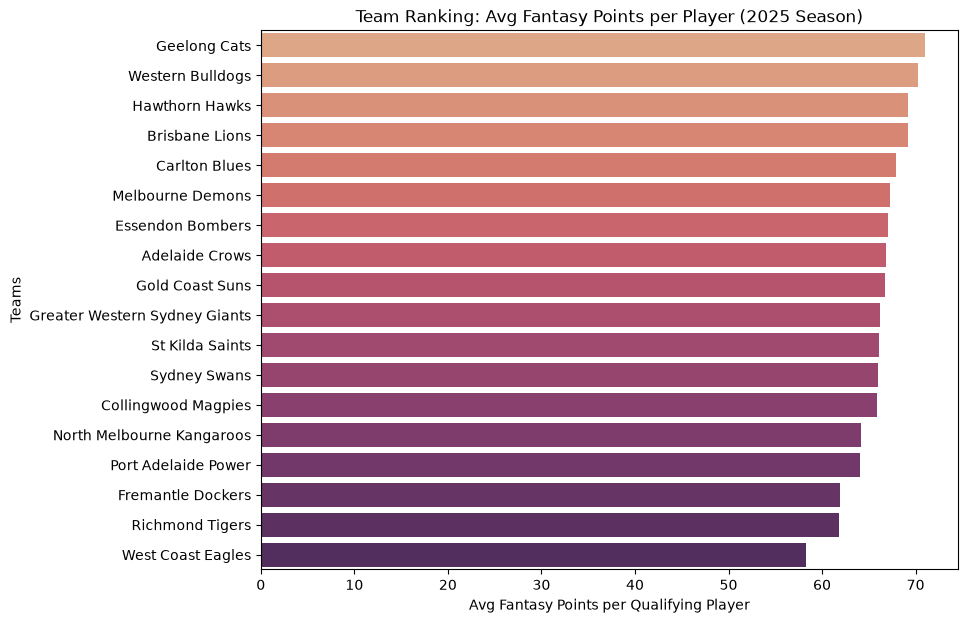

In [20]:
plt.figure(figsize=(9,7))
sns.barplot(data=team_rank, y='team', x='avg_team_fantasy_points', hue='team', palette='flare', legend=False)
plt.title('Team Ranking: Avg Fantasy Points per Player (2025 Season)')
plt.xlabel('Avg Fantasy Points per Qualifying Player')
plt.ylabel("Teams")
plt.show()

**Visualization 7: Correlation Between Key & Engineered Stats**

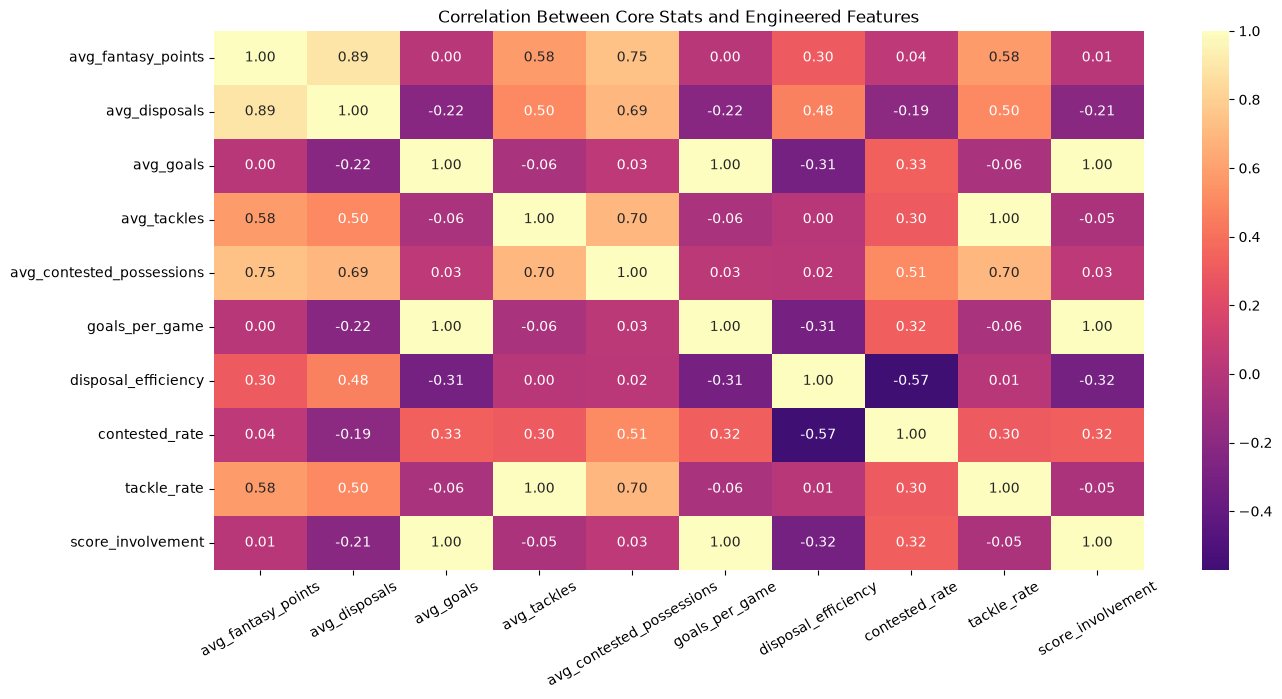

In [21]:
corr_cols = ['avg_fantasy_points','avg_disposals','avg_goals','avg_tackles','avg_contested_possessions',
             'goals_per_game','disposal_efficiency','contested_rate','tackle_rate','score_involvement']
plt.figure(figsize=(15,7))
sns.heatmap(season_25[corr_cols].corr(), annot=True, fmt='.2f', cmap='magma', center=0)
plt.title('Correlation Between Core Stats and Engineered Features')
plt.xticks(rotation = 30)
plt.show()

**Insight:** score_involvement and goals_per_game are almost perfectly correlated with each other, but only moderately correlated with avg_fantasy_points, disposal_efficienCy has close to zero correlation with raw disposal volume,

## 8. Task 5: Final Recommendations

I checked the following:

1. High **Performance Index** (overall value)
2. Low **CV** / high consistency 
3. Positive **trend**

I merged these three tables together and picked the players who show up strongly across the ones they qualify for.

In [28]:
recruit = season_25[['player_id','player_name','team','performance_index','avg_fantasy_points']].copy()
recruit = recruit.merge(consistency[['player_id','cv']], on='player_id', how='left')
recruit = recruit.merge(trend[['player_id','delta']], on='player_id', how='left')

# Rank within each available signal (lower rank = better). Missing signals just don't help/hurt score
recruit['rank_index'] = recruit['performance_index'].rank(ascending=False)
recruit['rank_cv'] = recruit['cv'].rank(ascending=True)
recruit['rank_trend'] = recruit['delta'].rank(ascending=False)

recruit['combined_rank_score'] = recruit[['rank_index','rank_cv','rank_trend']].mean(axis=1, skipna=True)
final_recs = recruit.sort_values('combined_rank_score').head(5)
recommended_players = final_recs[['player_name','team','avg_fantasy_points','performance_index','cv','delta']]
recommended_players

,player_name,team,avg_fantasy_points,performance_index,cv,delta
279,Sam Walsh,Carlton Blues,93.1,1.287550,0.197914,NaN
106,Isaac Heeney,Sydney Swans,96.9,1.620117,0.218573,15.060606
97,Errol Gulden,Sydney Swans,102.3,1.252248,0.203280,NaN
77,Tim English,Western Bulldogs,110.7,0.836224,0.169711,13.265152
33,Finn Callaghan,Greater Western Sydney Giants,99.0,1.198139,0.171082,9.100000


**Visualization 8: Final 5 Recommended Players: Value vs Consistency**

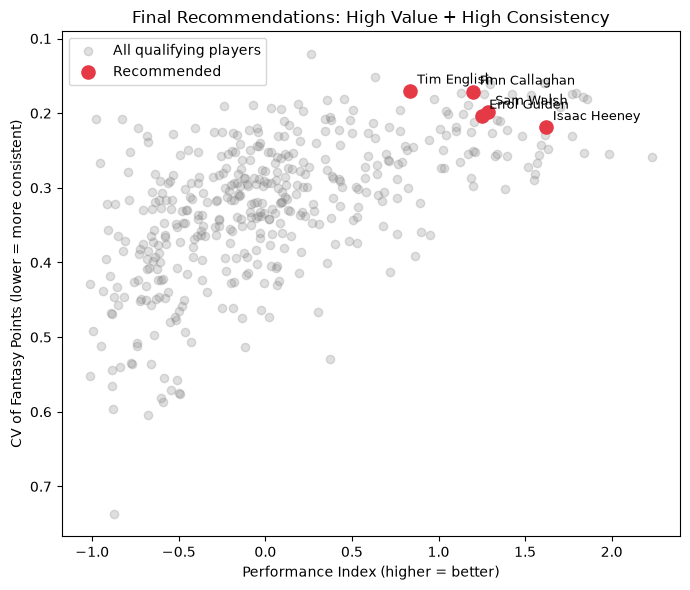

In [25]:
plt.figure(figsize=(7,6))
plt.scatter(season_25['performance_index'], consistency.set_index('player_id').reindex(season_25['player_id'])['cv'],
            alpha=0.25, color='grey', label='All qualifying players')
rec_plot = final_recs.merge(consistency[['player_id','cv']].rename(columns={'cv':'cv_plot'}), on='player_id', how='left')
plt.scatter(rec_plot['performance_index'], rec_plot['cv_plot'], color='#e63946', s=90, label='Recommended')
for _, row in rec_plot.iterrows():
    plt.annotate(row['player_name'], (row['performance_index'], row['cv_plot']), fontsize=9, xytext=(5,5), textcoords='offset points')
plt.gca().invert_yaxis()
plt.xlabel('Performance Index (higher = better)')
plt.ylabel('CV of Fantasy Points (lower = more consistent)')
plt.title('Final Recommendations: High Value + High Consistency')
plt.legend()
plt.tight_layout()
plt.show()

## 5 Recommended Players
* Sam Walsh	
* Isaac Heeney	
* Errol Gulden
* Tim English	
* Finn Callaghan

### 5 Recommended Players Summary

Based on the 2025 season data, here are the 5 recommended players, and why each one made the list 

- These players combine a **top-tier Performance Index** (strong across fantasy points, disposals, goals, tackles and contested possessions) with **low week-to-week variance**, meaning they're not just good on paper, they show up consistently.
- Where trend data was available, players who were also trending upward in the second half of the season were prioritized, since that suggests continued/improving form heading into next season rather than a player coasting on early-season form.
- All 5 are backed by the same combined ranking logic, so the recommendation isn't cherry-picked off a single stat, it's the players who score well across value, reliability, and momentum simultaneously.

# Business Insights

1. **The best players aren't always the highest goal scorers.** The top-ranked players are mostly midfielders because the index rewards overall performance, not just goals.
2. **Value and consistency are different.** Some players are very reliable but aren't among the highest-performing overall.
3. **Even consistent players have ups and downs.** No player performs at the exact same level every game.
4. **Player form changes during the season.** Many players improved or declined between the first and second half of the season.
5. **More disposals don't always mean better efficiency.** Getting the ball often doesn't guarantee using it well.
6. **score_involvement and goals_per_game are very similar.** Keeping both adds little extra value.
7. **Teams differ in overall player performance.** Some teams have stronger average player output than others.
8. **Filtering players with fewer than 10 games gives fairer results.** It removes players whose rankings are based on only a few games.
9. **Cleaning the data was important.** Many missing values were actually valid zeros and needed to be handled correctly.
10. **Using value, consistency, and form together gives a better ranking.** It provides a more balanced view than using a single statistic.
11. **Some of the biggest improvers weren't star players.** The analysis helps identify underrated talent.
